In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 |
| :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) |
| **`Chance of Admit`** | 정수 (Int) | $0$ 또는 $1$ | 합격 1, 불합격 0 |

In [8]:
base_path = r"C:\kdt_0900_osg\ml\resource\dataset"
file_name = r"admission_predict.csv"
file_path = os.path.join(base_path, file_name)

In [9]:
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0


In [10]:
admission_df = df.drop(["Unnamed: 0", "Serial No."], axis=1)
admission_df.columns = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Target']

In [11]:
admission_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          400 non-null    int64  
 1   TOEFL Score        400 non-null    int64  
 2   University Rating  400 non-null    int64  
 3   SOP                400 non-null    float64
 4   LOR                400 non-null    float64
 5   CGPA               400 non-null    float64
 6   Research           400 non-null    int64  
 7   Target             400 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 25.1 KB


In [12]:
admission_df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Target
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.450000
std,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.498117
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.000000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.000000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.000000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,1.000000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,1.000000


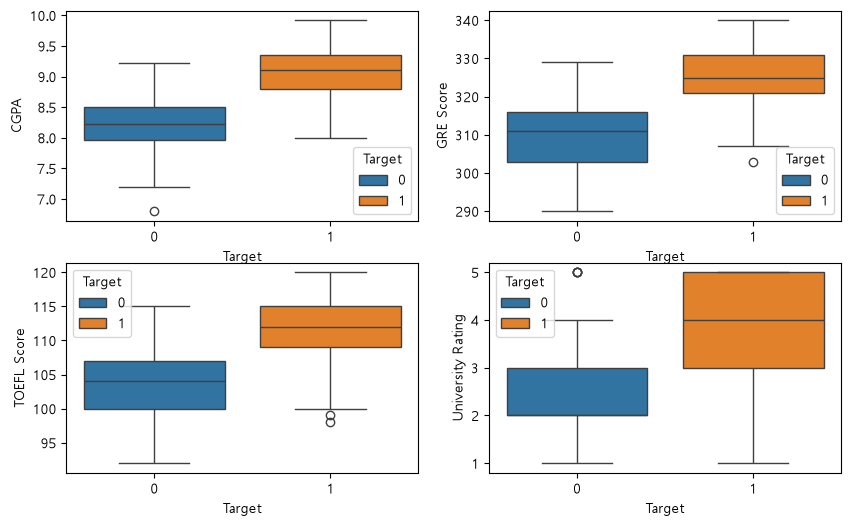

In [13]:
features = ["CGPA", "GRE Score", "TOEFL Score", "University Rating"]

plt.figure(figsize=(10, 6))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(admission_df, x="Target", y=feature, hue="Target")

plt.show()

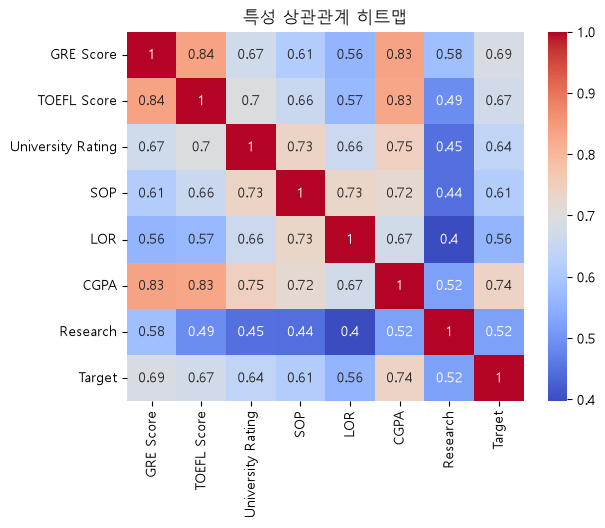

In [14]:
corr = admission_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("특성 상관관계 히트맵")
plt.show()

In [15]:
X = admission_df.drop("Target", axis=1)
X.head(3)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1


In [16]:
y = admission_df["Target"]
y.head(3)

0    1
1    1
2    0
Name: Target, dtype: int64

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [18]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)
print(X.columns)

[np.float64(4.61551616678161), np.float64(4.288959013746899), np.float64(2.9196056618253414), np.float64(3.075503721954348), np.float64(2.431258484869441), np.float64(5.207402545736424), np.float64(1.5433119011502867)]
Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research'],
      dtype='str')


In [19]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 7) (80, 7) (320,) (80,)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

## 규제(regularization)
- 머신러닝 모델이 train 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것
- 선형회귀 모델의 경우 특성에 곱해지는 계수 또는 기울기의 크기를 작게 만드는 일이다.
- 쉽게 말하자면 선형회귀 모델의 성능을 끌어올리기 위한 방법이다.
- 
#### 1) 릿지(ridge)
- 계수를 제곱한 값을 기준으로 규제를 적용한다. (일반적으로 선호)
- 조금 넘을 때는 벌금이 적지만, 과속이 심해질수록 벌금이 제곱으로 폭발하도록 설계된다.  
  즉, 작은 값으로 연산하여 값이 폭발하는 것을 방지함.
- 예를 들어 $z = (2.5 \times 100) + b = 250 + b$를
- $z = (0.008 \times 100) + b = 0.8 + b$


#### 2) 라쏘(lasso)
- 계수의 절댓값을 기준으로 규제를 적용한다. 영향을 주지 않는 가중치는 과감하게 빼버림 (가중치가 작든 크든 줄어드는 비율이 일정)
- $z = $$z = w_1 \cdot (\text{연봉}) + w_2 \cdot (\text{나이}) + w_3 \cdot (\text{성별}) + b$$
- $z = $$z = w_1 \cdot (\text{연봉}) + 0 \cdot (\text{나이}) + 0 \cdot (\text{성별}) + b$$

# 데이터 표준화

In [23]:
scaler = StandardScaler()

In [25]:
X_train_scaled = scaler.fit_transform(X_train)
X_text_scaled = scaler.transform(X_test)

In [28]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01)
}

result = []
coef_df = pd.DataFrame(index=X.columns)

for name, model in models.items():
    # 학습
    model.fit(X_train_scaled, y_train)

    # 예측
    y_pred = model.predict(X_test_scaled)    
    
    # 평가
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    y_pred_class = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_class)

    result.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "Acurracy": acc
    })

    coef_df[name] = model.coef_

In [ ]:
result_df = pd.DataFrame(result)

In [29]:
coef_df.sort_values(by="LinearRegression", ascending=False)

,LinearRegression,Ridge,Lasso
CGPA,0.170626,0.168599,0.169111
GRE Score,0.076086,0.076236,0.075305
University Rating,0.069660,0.069725,0.066634
Research,0.064450,0.064335,0.058810
SOP,0.055002,0.054779,0.048769
TOEFL Score,0.009755,0.010982,0.008198
LOR,-0.004585,-0.003801,0.000000


In [35]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

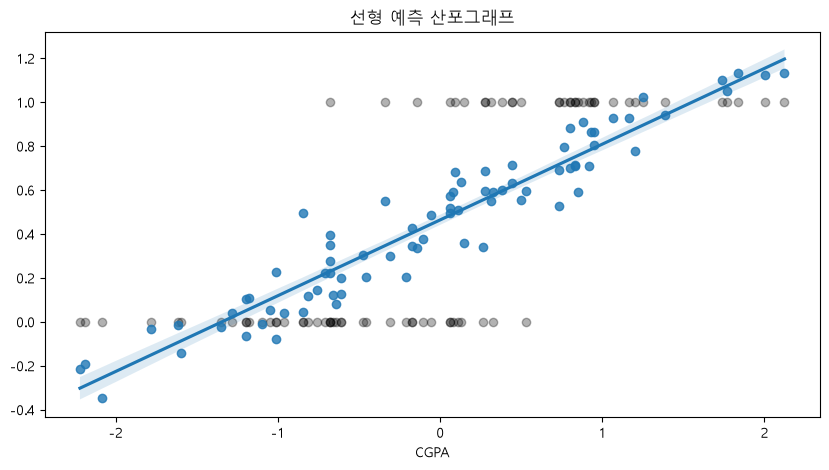

In [41]:
plt.figure(figsize=(10, 5))

plt.scatter(X_test_scaled_df["CGPA"], y_test, color="black", alpha=0.3, label="Actual")
sns.regplot(x=X_test_scaled_df["CGPA"], y=model.predict(X_test_scaled))

plt.title("선형 예측 산포그래프")
plt.show()

In [43]:
lr = LogisticRegression()

In [44]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [45]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [46]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_percent = y_prob * 100

for i, prob in enumerate(y_prob_percent[:20], 1):
    print(f"샘플 {i}번의 합격 확률: {prob:.2f}")

샘플 1번의 합격 확률: 98.86
샘플 2번의 합격 확률: 5.62
샘플 3번의 합격 확률: 6.88
샘플 4번의 합격 확률: 0.09
샘플 5번의 합격 확률: 0.24
샘플 6번의 합격 확률: 14.38
샘플 7번의 합격 확률: 24.86
샘플 8번의 합격 확률: 0.24
샘플 9번의 합격 확률: 6.15
샘플 10번의 합격 확률: 99.88
샘플 11번의 합격 확률: 80.96
샘플 12번의 합격 확률: 0.35
샘플 13번의 합격 확률: 96.18
샘플 14번의 합격 확률: 99.66
샘플 15번의 합격 확률: 98.39
샘플 16번의 합격 확률: 89.61
샘플 17번의 합격 확률: 75.23
샘플 18번의 합격 확률: 0.29
샘플 19번의 합격 확률: 52.76
샘플 20번의 합격 확률: 94.89


In [47]:
acc = accuracy_score(y_test, y_pred)
print(f"로지스틱 회귀 정확도: {acc}")

로지스틱 회귀 정확도: 0.8875


In [51]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
5,CGPA,1.752864
0,GRE Score,0.662403
3,SOP,0.627480
2,University Rating,0.506172
6,Research,0.357107
1,TOEFL Score,0.324889
4,LOR,0.146161


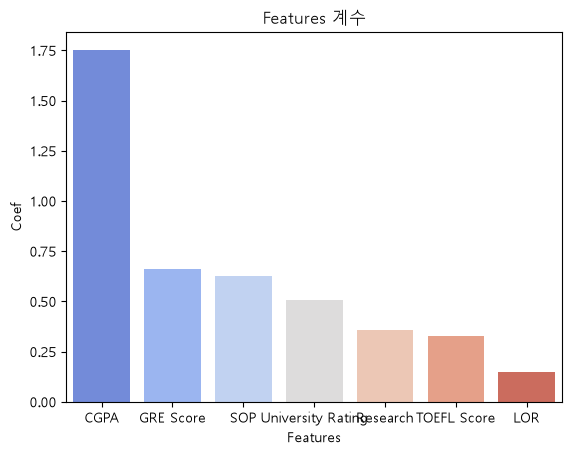

In [54]:
sns.barplot(coef_df, x="Features", y= "Coef", palette="coolwarm", hue="Features")

plt.title("Features 계수")
plt.show()

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.86      0.89        44
           1       0.85      0.92      0.88        36

    accuracy                           0.89        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.89      0.89      0.89        80

